<a href="https://colab.research.google.com/github/FabioPira/TelecomX_LATAM_2/blob/main/TelecomX_LATAM_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

TelecomX_Procesado = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/TelecomX_Procesado.csv')

In [3]:
TelecomX_Procesado.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,0,0,0,1,1,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,1,0,0,0,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,1,0,0,0,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,1,1,1,0,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,0,1,1,0,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [4]:
# Identificar columnas categóricas
columnas_categoricas = TelecomX_Procesado.select_dtypes(include='object').columns

# Aplicar One-Hot Encoding
TelecomX_Procesado_encoded = pd.get_dummies(
    TelecomX_Procesado,
    columns=columnas_categoricas,
    drop_first=True
)

# Verificar resultado
TelecomX_Procesado_encoded.head()

,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,account.PaperlessBilling,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias,...,internet.TechSupport_Yes,internet.StreamingTV_No internet service,internet.StreamingTV_Yes,internet.StreamingMovies_No internet service,internet.StreamingMovies_Yes,account.Contract_One year,account.Contract_Two year,account.PaymentMethod_Credit card (automatic),account.PaymentMethod_Electronic check,account.PaymentMethod_Mailed check
0,0,0,0,1,1,9,1,65.6,593.30,2.186667,...,True,False,True,False,False,True,False,False,False,True
1,0,1,0,0,0,9,0,59.9,542.40,1.996667,...,False,False,False,False,True,False,False,False,False,True
2,1,1,0,0,0,4,1,73.9,280.85,2.463333,...,False,False,False,False,False,False,False,False,True,False
3,1,1,1,1,0,13,1,98.0,1237.85,3.266667,...,False,False,True,False,True,False,False,False,True,False
4,1,0,1,1,0,3,1,83.9,267.40,2.796667,...,True,False,True,False,False,False,False,False,False,True


# Verificación de la Proporción de Cancelación (Churn) #

In [5]:
# Proporción de clientes por clase
proporcion_churn = TelecomX_Procesado_encoded['Churn'].value_counts(normalize=True)

proporcion_churn

,proportion
Churn,
0,0.73463
1,0.26537


clientes que permanecen
clientes que cancelaron
73% permanecen
27% cancelan

In [6]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Separar variables predictoras (X) y variable objetivo (y)
X = TelecomX_Procesado_encoded.drop('Churn', axis=1)
y = TelecomX_Procesado_encoded['Churn']

# Dividir datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Aplicar SMOTE solo en el conjunto de entrenamiento
smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Verificar nuevo balance de clases
y_train_bal.value_counts(normalize=True)

,proportion
Churn,
0,0.5
1,0.5


In [7]:
from sklearn.preprocessing import StandardScaler

# Inicializar el escalador
scaler = StandardScaler()

# Ajustar y transformar los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train_bal)

# Transformar los datos de prueba
X_test_scaled = scaler.transform(X_test)

# Correlación y Selección de Variables #

## Análisis de Correlación ##

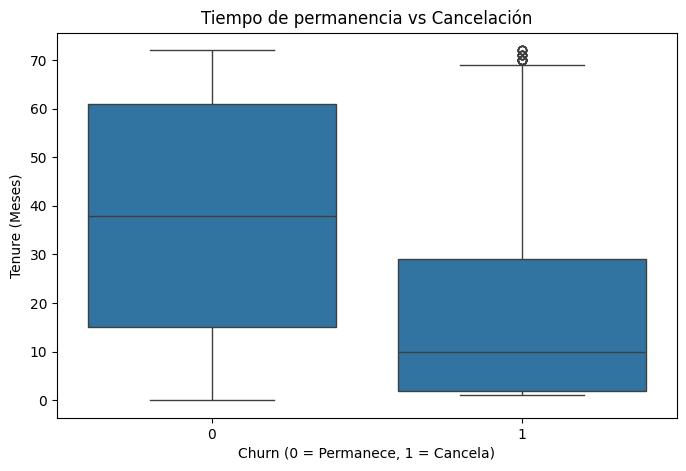

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="customer.tenure",
    data=TelecomX_Procesado
)

plt.title("Tiempo de permanencia vs Cancelación")
plt.xlabel("Churn (0 = Permanece, 1 = Cancela)")
plt.ylabel("Tenure (Meses)")

plt.show()

Se observa que los clientes que cancelan el servicio suelen tener un tiempo de permanencia menor, mientras que los clientes que continúan con la empresa presentan tenure significativamente más alto.

Esto indica que los primeros meses del cliente son críticos para la retención.
Muchos clientes que cancelan lo hacen antes de consolidar una relación de largo plazo con la empresa.

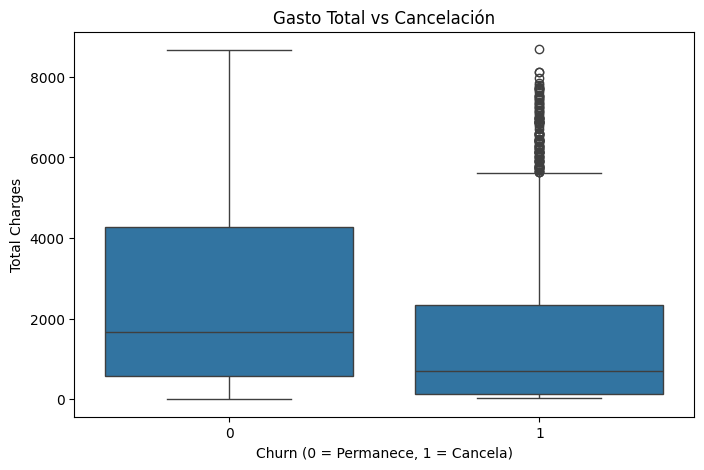

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="account.Charges.Total",
    data=TelecomX_Procesado
)

plt.title("Gasto Total vs Cancelación")
plt.xlabel("Churn (0 = Permanece, 1 = Cancela)")
plt.ylabel("Total Charges")

plt.show()

Los clientes que cancelan el servicio tienen en promedio un gasto total menor, mientras que los clientes que permanecen presentan valores de gasto total más altos.
Esto ocurre porque los clientes que cancelan suelen hacerlo en etapas tempranas del contrato, por lo que no alcanzan a acumular un gasto elevado.

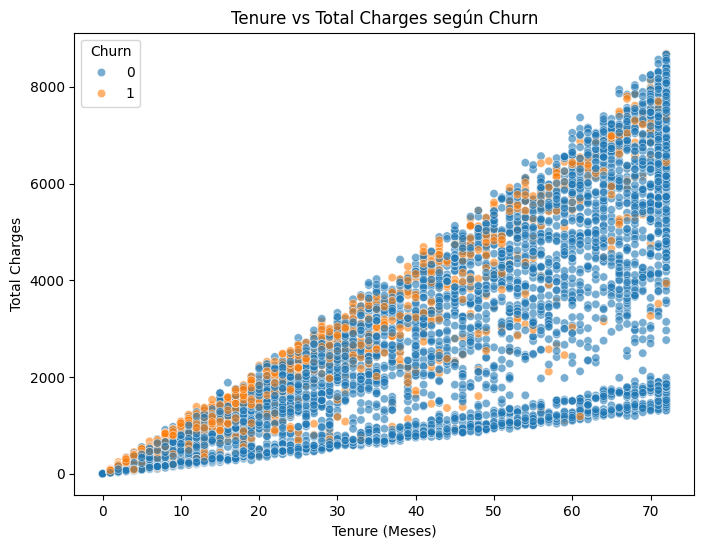

In [13]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="customer.tenure",
    y="account.Charges.Total",
    hue="Churn",
    data=TelecomX_Procesado,
    alpha=0.6
)

plt.title("Tenure vs Total Charges según Churn")
plt.xlabel("Tenure (Meses)")
plt.ylabel("Total Charges")

plt.show()

Esto sugiere que la permanencia del cliente está fuertemente relacionada con su valor económico para la empresa.
Clientes que logran mantenerse por más tiempo tienden a generar mayor ingreso y menor riesgo de cancelación.

*Modelado Predictivo*

In [14]:
from sklearn.model_selection import train_test_split

# Separar variables predictoras (X) y variable objetivo (y)
X = TelecomX_Procesado_encoded.drop('Churn', axis=1)
y = TelecomX_Procesado_encoded['Churn']

# Dividir el dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% para prueba
    random_state=42,    # reproducibilidad
    stratify=y          # mantiene la proporción de churn
)

# Verificar tamaños
print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (5634, 7073)
Datos de prueba: (1409, 7073)


**Creación de Modelos**

In [15]:
from sklearn.linear_model import LogisticRegression

# Entrenar modelo
modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train_scaled, y_train_bal)

# Predicciones
y_pred_log = modelo_logistico.predict(X_test_scaled)

In [16]:
from sklearn.ensemble import RandomForestClassifier

# Crear modelo
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Entrenar modelo
modelo_rf.fit(X_train_bal, y_train_bal)

# Predicciones
y_pred_rf = modelo_rf.predict(X_test)

Los modelos basados en árboles de decisión, como Random Forest o Decision Trees, no requieren este preprocesamiento, ya que dividen los datos mediante reglas de partición y no mediante cálculos de distancia

In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: Regresión Logística (requiere datos normalizados)
log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)


# Modelo 2: Random Forest (no requiere normalización)
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


Regresión Logística
Accuracy: 0.7338537970191625
Precision: 0.0
Recall: 0.0
F1-score: 0.0

Reporte de Clasificación
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



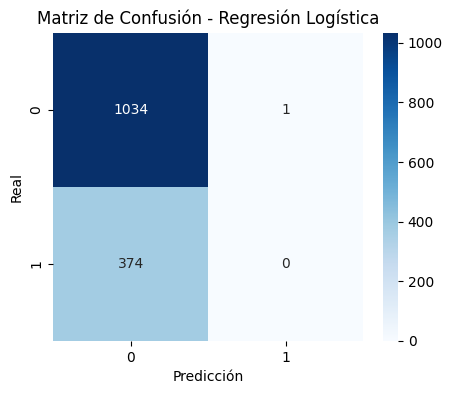

Random Forest
Accuracy: 0.7984386089425124
Precision: 0.6691729323308271
Recall: 0.47593582887700536
F1-score: 0.55625

Reporte de Clasificación
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.67      0.48      0.56       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.71      1409
weighted avg       0.79      0.80      0.79      1409



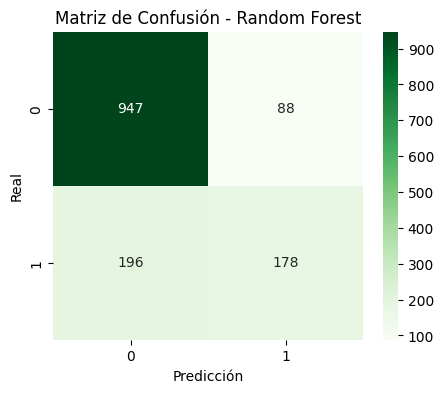

In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# =========================
# Predicciones de los modelos
# =========================

y_pred_log = log_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)

# =========================
# Métricas Regresión Logística
# =========================

print("Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\nReporte de Clasificación")
print(classification_report(y_test, y_pred_log))

# Matriz de confusión
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Regresión Logística")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


# =========================
# Métricas Random Forest
# =========================

print("Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("\nReporte de Clasificación")
print(classification_report(y_test, y_pred_rf))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

**Regresión Logística**

El modelo de Regresión Logística muestra signos claros de underfitting.

Evidencia observada:

No logra identificar clientes que cancelan (TP = 0).

Presenta un número elevado de falsos negativos (374).

El modelo predice casi siempre la clase mayoritaria (clientes que no cancelan).

Interpretación

Esto indica que el modelo es demasiado simple para capturar las relaciones complejas presentes en los datos, especialmente cuando el dataset presenta desbalance entre clases.

**Random Forest**

El modelo de Random Forest no presenta señales claras de overfitting en los resultados observados.

Evidencia observada:

Detecta correctamente 178 clientes que cancelan.

Presenta una distribución más equilibrada entre verdaderos positivos y falsos negativos.

Captura mejor los patrones del dataset.

Interpretación

Esto indica que el modelo logra aprender relaciones más complejas entre las variables, permitiendo identificar clientes con riesgo de cancelación de forma más efectiva.

Posibles mejoras

Aunque el modelo tiene buen desempeño, se podría optimizar mediante:

Ajuste de hiperparámetros (número de árboles, profundidad máxima, etc.).

Validación cruzada.

Ingeniería de características adicionales.

📋 **Interpretación y Conclusiones**

Análisis de la Importancia de las Variables

In [23]:
import pandas as pd

# Obtener coeficientes
coeficientes = pd.DataFrame({
    "Variable": X_train.columns,
    "Coeficiente": log_model.coef_[0]
})

# Ordenar por importancia
coeficientes = coeficientes.sort_values(by="Coeficiente", ascending=False)

coeficientes.head(10)

,Variable,Coeficiente
7054,internet.InternetService_Fiber optic,0.510199
7071,account.PaymentMethod_Electronic check,0.453720
5,account.PaperlessBilling,0.276398
1,customer.SeniorCitizen,0.215022
8,Cuentas_Diarias,0.201439
6,account.Charges.Monthly,0.201439
6102,customerID_8631-NBHFZ,0.186831
4489,customerID_6323-AYBRX,0.185360
416,customerID_0607-DAAHE,0.185256
2383,customerID_3400-ESFUW,0.185256


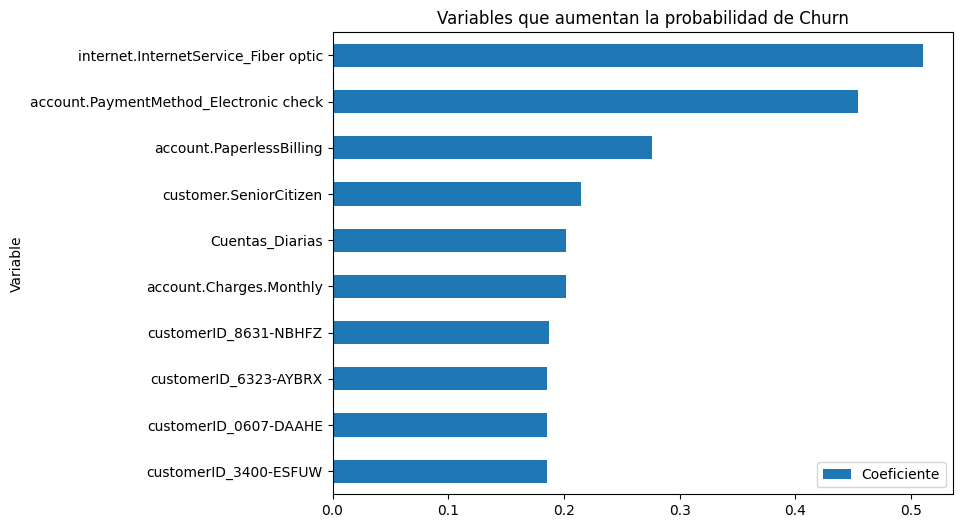

In [24]:
import matplotlib.pyplot as plt

coeficientes.sort_values(by="Coeficiente").tail(10).plot(
    x="Variable",
    y="Coeficiente",
    kind="barh",
    figsize=(8,6)
)

plt.title("Variables que aumentan la probabilidad de Churn")
plt.show()

Analizar importancia de variables en Random Forest

In [25]:
importances = rf_model.feature_importances_

rf_importancia = pd.DataFrame({
    "Variable": X_train.columns,
    "Importancia": importances
})

rf_importancia = rf_importancia.sort_values(by="Importancia", ascending=False)

rf_importancia.head(10)

,Variable,Importancia
7,account.Charges.Total,0.093336
4,customer.tenure,0.093274
6,account.Charges.Monthly,0.072755
8,Cuentas_Diarias,0.071476
7071,account.PaymentMethod_Electronic check,0.026080
7069,account.Contract_Two year,0.023293
7054,internet.InternetService_Fiber optic,0.019249
7057,internet.OnlineSecurity_Yes,0.018437
7063,internet.TechSupport_Yes,0.018318
5,account.PaperlessBilling,0.017483


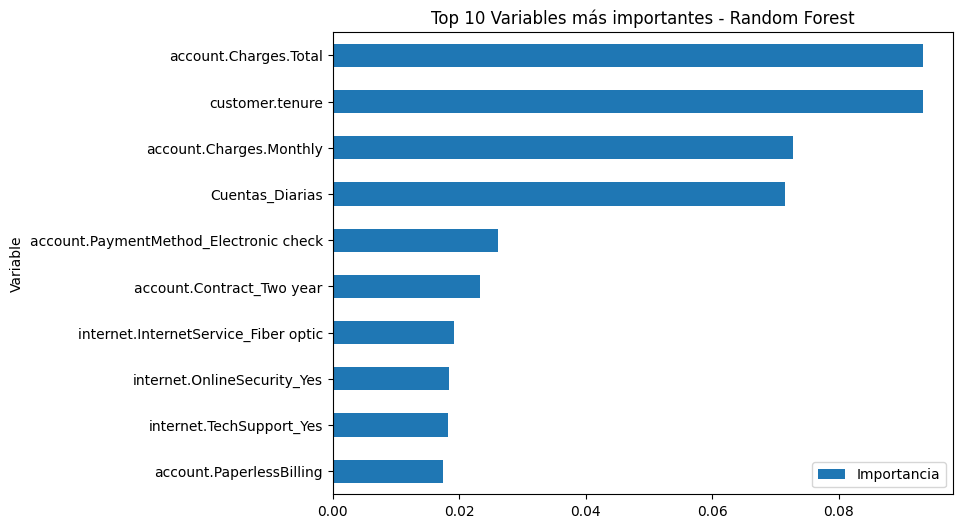

In [26]:
rf_importancia.head(10).plot(
    x="Variable",
    y="Importancia",
    kind="barh",
    figsize=(8,6)
)

plt.title("Top 10 Variables más importantes - Random Forest")
plt.gca().invert_yaxis()
plt.show()

Variables que suelen aparecer importantes:

*   Tipo de contrato
*   tenure (tiempo de permanencia)
*   cargos mensuales
*   servicios adicionales
*   tipo de pago

**Conclusión**

Los clientes con menor tiempo en la empresa tienen mayor probabilidad de cancelar

El análisis mostró que el tiempo de permanencia (tenure) es una de las variables más influyentes en la cancelación. Los clientes que llevan menos tiempo utilizando el servicio presentan una mayor tendencia a abandonar la compañía. Esto sugiere que los primeros meses de relación con el cliente son críticos, por lo que estrategias de acompañamiento y fidelización temprana podrían reducir significativamente el churn.

Los clientes con menor tiempo en la empresa tienen mayor probabilidad de cancelar

El análisis mostró que el tiempo de permanencia (tenure) es una de las variables más influyentes en la cancelación. Los clientes que llevan menos tiempo utilizando el servicio presentan una mayor tendencia a abandonar la compañía. Esto sugiere que los primeros meses de relación con el cliente son críticos, por lo que estrategias de acompañamiento y fidelización temprana podrían reducir significativamente el churn.

El modelo Random Forest demuestra mayor capacidad para identificar clientes en riesgo

Al comparar los modelos desarrollados, el Random Forest logró identificar correctamente una cantidad considerable de clientes que realmente cancelaron, mientras que la regresión logística mostró limitaciones para detectar estos casos. Esto indica que modelos basados en árboles de decisión pueden capturar mejor patrones complejos en los datos, convirtiéndose en una herramienta más adecuada para anticipar la cancelación y apoyar estrategias de retención de clientes.